# 패키지 import

# Phase 1 

  ✓ pyaedt_actuator 패키지 구조 생성
  ✓ ActuatorDesignSpec 클래스 완성

# Phase 2 (이번주 )

  □ geometry.py 함수 구현 (step-by-step)
  □ 2D 기하학 생성 및 시각화 검증

# Phase 3 Maxwell 연동

  □ AEDT 프로젝트 생성 및 설계 파라미터 적용
  □ 시뮬레이션 실행 및 결과 추출

In [ ]:
✅ Day 6-7 (다음 주 초)
  □ maxwell_bridge.py 개발
  □ Maxwell 모델 생성 검증

## Maxwell GUI에서 Actuator 모델링 (라인바이라인)

이 섹션은 Maxwell GUI에서 수행하는 모든 작업을 **pyAEDT 명령어로 라인바이라인 구현**합니다.

## 📌 목표
회전 액추에이터(Rotary Motor)를 Maxwell 2D에서 모델링하는 전체 과정을 단계별로 실행

## 🎯 워크플로우
```
Step 1: 프로젝트 생성 & 기본 설정
Step 2: 기하학 생성 (스테이터, 로터, 에어갭)
Step 3: 재료 할당 & 코일 정의
Step 4: 경계 & 여기 조건 설정
Step 5: 메시 생성
Step 6: 시뮬레이션 실행 & 결과 추출
```

## Step 1: 라이브러리 Import & 기본 설정

In [1]:
Notebook_path='E:\KDH\gitDosa_Actuator\SimMaxwell'

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# pyAEDT import
from ansys.aedt.core import Maxwell2d
from ansys.aedt.core import Desktop

# 설정
AEDT_VERSION = "2026.1"
NON_GRAPHICAL = False  # GUI 표시 (False = 표시)

print("✅ Libraries imported successfully")
print(f"   AEDT Version: {AEDT_VERSION}")
print(f"   Non-graphical mode: {NON_GRAPHICAL}")

✅ Libraries imported successfully
   AEDT Version: 2026.1
   Non-graphical mode: False


## Step 3: Maxwell 프로젝트 생성 및 초기화

In [3]:
# PROJECT_NAME = f"RotaryMotor_{PARAMS['pole_pairs']}P_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
PROJECT_NAME = "Axi_Magnetostatic_Actuator"
SOLUTION_TYPE = "MagnetostaticZ"
Design_NAME = "01_Actuator" 
import os
fullfilePath=os.path.join(Notebook_path, f"{PROJECT_NAME}.aedt")
print(f"\n✅ Project file path: {fullfilePath}")
print("🚀 Creating Maxwell 2D project...")
print(f"   Project: {PROJECT_NAME}")
print(f"   Solution: {SOLUTION_TYPE}")



✅ Project file path: E:\KDH\gitDosa_Actuator\SimMaxwell\Axi_Magnetostatic_Actuator.aedt
🚀 Creating Maxwell 2D project...
   Project: Axi_Magnetostatic_Actuator
   Solution: MagnetostaticZ


In [4]:
# 통합 초기화 셀 (기존 셀 15~18 통합)
# - 프로젝트 파일 존재 여부 확인
# - Desktop 세션 확인/연결
# - 현재 열린 프로젝트 확인 후 load/create
# - Design 연결 및 solution type 정합
# - 기본 단위(mm) 설정 및 저장

import os


def _norm_path(p):
    if not p:
        return ""
    return os.path.normcase(os.path.normpath(str(p)))


def _norm_solution(s):
    return str(s).strip().lower().replace(" ", "").replace("-", "")


def _is_axis_about_z(s):
    n = _norm_solution(s)
    return n.endswith("z") or n.endswith("aboutz")


def _to_api_solution(s):
    alias = {
        "magnetostaticz": "Magnetostatic",
        "magnetostatic2d": "Magnetostatic",
        "magnetostaticaboutz": "Magnetostatic",
        "transientz": "Transient",
        "transient2d": "Transient",
        "electrostaticz": "Electrostatic",
    }
    n = _norm_solution(s)
    return alias.get(n, str(s))


# 0) 경로 준비
fullfilePath = os.path.abspath(fullfilePath)
project_exists = os.path.exists(fullfilePath)
print(f"Target project path: {fullfilePath}")
print(f"Project file exists: {project_exists}")

# 1) Desktop 세션 연결(열려 있지 않으면 시작)
desktop = Desktop(version=AEDT_VERSION, non_graphical=NON_GRAPHICAL, new_desktop=False)
print("✅ Desktop session connected")

# 2) 현재 열린 프로젝트 확인
current_project = None
try:
    project_path_attr = desktop.project_path
    current_project = project_path_attr() if callable(project_path_attr) else project_path_attr
except Exception:
    current_project = None

current_project_norm = _norm_path(current_project)
target_project_norm = _norm_path(fullfilePath)
print(f"Current project: {current_project}")

# 3) 프로젝트 open/create
if project_exists:
    if current_project_norm != target_project_norm:
        print("ℹ️ Existing project file found. Loading target project...")
        desktop.load_project(fullfilePath)
        print("✅ Target project loaded")
    else:
        print("✅ Target project already open")
else:
    print("ℹ️ Project file not found. Creating new project file...")
    m2d = Maxwell2d(
        project=fullfilePath,
        design=Design_NAME,
        solution_type=SOLUTION_TYPE,
        version=AEDT_VERSION,
        non_graphical=NON_GRAPHICAL,
        new_desktop=False,
    )
    m2d.modeler.model_units = "mm"
    m2d.save_project(file_name=fullfilePath)
    print("✅ New project created and saved")

# 4) Design 연결
m2d = Maxwell2d(
    project=fullfilePath,
    design=Design_NAME,
    version=AEDT_VERSION,
    non_graphical=NON_GRAPHICAL,
    new_desktop=False,
)
print(f"✅ Active design connected: {m2d.design_name} ({m2d.solution_type})")

# 5) Solution type 정합
target_solution_raw = str(SOLUTION_TYPE)
target_solution_api = _to_api_solution(target_solution_raw)
use_about_z = _is_axis_about_z(target_solution_raw)
current_solution = str(m2d.solution_type)

if _norm_solution(current_solution) != _norm_solution(target_solution_api):
    print("ℹ️ Solution type mismatch detected. Trying to update...")
    changed = False

    try:
        if use_about_z and _norm_solution(target_solution_api) == "magnetostatic":
            m2d.odesign.SetSolutionType("Magnetostatic", "about Z")
        else:
            try:
                m2d.odesign.SetSolutionType(target_solution_api)
            except TypeError:
                m2d.odesign.SetSolutionType(target_solution_api, "")
        changed = True
    except Exception as e:
        print(f"⚠️ SetSolutionType failed: {e}")

    if changed:
        m2d = Maxwell2d(
            project=fullfilePath,
            design=Design_NAME,
            version=AEDT_VERSION,
            non_graphical=NON_GRAPHICAL,
            new_desktop=False,
        )
        print(f"✅ Solution type updated: {m2d.solution_type}")

# 6) 공통 기본 설정 저장
m2d.modeler.model_units = "mm"
m2d.save_project(file_name=fullfilePath)

print("\n✅ Unified initialization complete")
print(f"   Project: {m2d.project_name}")
print(f"   Design: {m2d.design_name}")
print(f"   Solution: {m2d.solution_type}")
print(f"   Units: {m2d.modeler.model_units}")

Target project path: E:\KDH\gitDosa_Actuator\SimMaxwell\Axi_Magnetostatic_Actuator.aedt
Project file exists: True
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 50051.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 50051.
✅ Desktop session connected
Current project: E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA/output/maxwell_live_solenoid/
ℹ️ Existing project file found. Loading target project...
PyAEDT INFO: Active Design set to 01_Actuator
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 19404!
PyAEDT INFO: Project Axi_Mag

In [ ]:
# 통합됨: 셀 15에서 모델 단위(mm) 설정 및 저장까지 처리합니다.

In [ ]:
# 통합됨: 셀 15에서 프로젝트 저장을 처리합니다.

In [ ]:
# 통합됨: 셀 15에서 Desktop 세션 연결, 프로젝트 open/create, design/solution 정합을 처리합니다.

PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.25.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: New AEDT session is starting on gRPC port 49869.
PyAEDT INFO: Starting new AEDT gRPC session on port 49869.
PyAEDT INFO: Launching AEDT server with gRPC transport mode: wnua
PyAEDT INFO: Electronics Desktop started on gRPC port 49869 after 25.6 seconds.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 49869.
Current project: None
Target project: E:\KDH\gitDosa_Actuator\SimMaxwell\Axi_Magnetostatic_Actuator.aedt

⚠️ Different project is open (or no project open). Loading target project...
PyAEDT INFO: Active Design set to 02_Actuator_Transient
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAED

## Step 4: 기하학 생성 - TRC(교육자료기준)

In [5]:
# design parameters
m2d["move"] = "0mm"  # Displacement applied to anchor

# Coil
coil_m = m2d.modeler.create_rectangle(origin=["3mm", "0mm", "7mm"], sizes=[-14, 6], name="Coil", material="Copper")
# Anchor
anchor_m = m2d.modeler.create_rectangle(
    origin=["0mm", "0mm", "13mm - move"],
    sizes=[-8, 2],
    name="Anchor",
    material="steel_1008",
)

# Housing
points_housing = [
    [0, 0, 0],
    [0, 0, -10],
    [12, 0, -10],
    [12, 0, 10],
    [2.5, 0, 10],
    [2.5, 0, 8],
    [10, 0, 8],
    [10, 0, -8],
    [2, 0, -8],
    [2, 0, 0],
]

# Create 
housing_m = m2d.modeler.create_polyline(points_housing, close_surface=True, name="Housing", material="steel_1008")
m2d.modeler.cover_lines(housing_m)

PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


True

## Step 9: 경계 조건 설정

In [6]:
region_m = m2d.modeler.create_region(pad_percent=100)


PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT ERROR: Region object already exists


In [7]:
region_m.material_name = "vacuum"
region_m.edges
m2d.assign_vector_potential(assignment=region_m.edges, boundary="VectorPotential1")


AttributeError: 'bool' object has no attribute 'material_name'

## excitation

In [ ]:
m2d["Amp_1"] = "1000A"  # Net current applied to coil
m2d.assign_current(assignment=coil_m.name, amplitude="Amp_1", name="Current1")


## force parameter

In [ ]:
m2d.assign_force(
    assignment=anchor_m,
    force_name="Force",
)

## Solution Setpup

In [ ]:
setup = m2d.create_setup("MySetup")
print(setup.props)
setup.props["MaximumPasses"] = 3
setup.props["PercentRefinement"] = 30
setup.props["PercentError"] = 0.1
setup.props["MinimumPasses"] = 1
setup.props["RelativeResidual"] = 1e-6

## Create variable for force calculation & parameter sweeps

In [ ]:
# Enable sweeps over coil net current and anchor displacement

value_sweep = m2d.parametrics.add("Amp_1", 500, 2000, 500, name="ParametricSetup1", variation_type="LinearStep")
value_sweep.add_variation("move", 0, 4, 1, variation_type="LinearStep")
#

## Save project before simulation

In [ ]:
m2d.save_project()


## Run Sweep

In [34]:
NUM_CORES=8
value_sweep.analyze(cores=NUM_CORES)


NameError: name 'value_sweep' is not defined

## Visualize results

In [5]:
m2d.post.create_report(
    expressions=["Force.Force_z"],
    variations={"Amp_1": "All", "move": "All"},
    plot_name="Force Plot 1",
    primary_sweep_variable="move",
    plot_type="Rectangular Plot",
)



PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 1sec
PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic


Force Plot 1

PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic
PyAEDT INFO: Solution Data Correctly Loaded.
Time to initialize solution data:0.04945945739746094
Time to initialize solution data:0.0734710693359375
PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic
PyAEDT INFO: Solution Data Correctly Loaded.
Time to initialize solution data:0.04564070701599121
Time to initialize solution data:0.06864213943481445
PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic
PyAEDT INFO: Solution Data Correctly Loaded.
Time to initialize solution data:0.04800701141357422
Time to initialize solution data:0.07301974296569824


c:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:640: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic
PyAEDT INFO: Solution Data Correctly Loaded.
Time to initialize solution data:0.04778909683227539
Time to initialize solution data:0.07285833358764648
PyAEDT WARNING: No report category provided. Automatically identified Magnetostatic
PyAEDT INFO: Solution Data Correctly Loaded.
Time to initialize solution data:0.04520845413208008
Time to initialize solution data:0.06820988655090332


,Amp_1,move,Force.Force_z
0,1000.0,0.0,-0.458280
1,1000.0,1.0,-0.734834
2,1000.0,2.0,-1.203828
3,1000.0,3.0,-1.967897
4,1000.0,4.0,-4.724997
5,1500.0,0.0,-1.031852
6,1500.0,1.0,-1.654473
7,1500.0,2.0,-2.704838
8,1500.0,3.0,-4.319193
9,1500.0,4.0,-8.838601


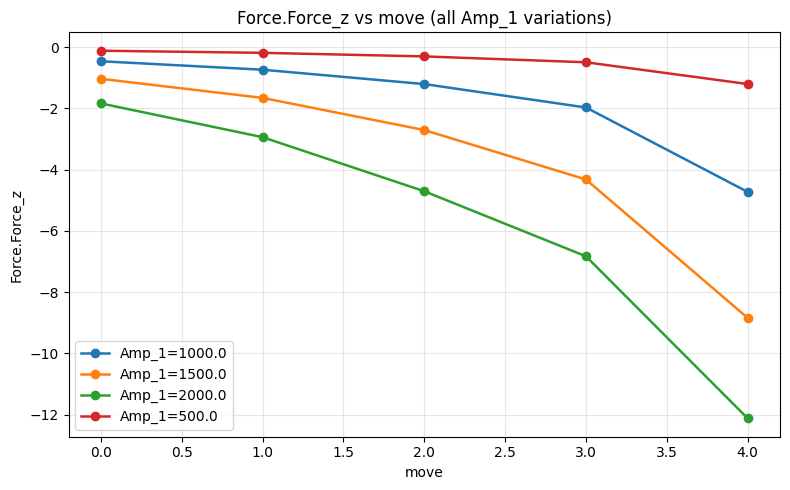

In [10]:
# 셀 37 리포트 조건과 동일하게 2개 variation(Amp_1, move) 전체 데이터 추출/시각화

expr = "Force.Force_z"
rows = []

# 1) Amp_1 축 값을 먼저 탐색 (primary sweep을 Amp_1로 조회)
amp_probe = m2d.post.get_solution_data(
    expressions=[expr],
    variations={"Amp_1": "All", "move": "All"},
    primary_sweep_variable="Amp_1",
)

if amp_probe is None:
    raise RuntimeError("Solution data를 가져오지 못했습니다. 먼저 해석/스윕이 완료되었는지 확인하세요.")

amp_values_obj = getattr(amp_probe, "primary_sweep_values", None)
amp_values_raw = list(amp_values_obj) if amp_values_obj is not None else []
amp_values = []
for v in amp_values_raw:
    s = str(v)
    if s not in amp_values:
        amp_values.append(s)

# Amp_1 값 탐색이 실패하면 기존 설정 범위를 fallback으로 사용
if not amp_values:
    amp_values = ["500A", "1000A", "1500A", "2000A"]

# 2) Amp_1 값별로 move sweep을 개별 조회
for amp in amp_values:
    sd = m2d.post.get_solution_data(
        expressions=[expr],
        variations={"Amp_1": amp, "move": "All"},
        primary_sweep_variable="move",
    )
    if sd is None:
        continue

    x_vals = np.array(sd.primary_sweep_values, dtype=float)
    y_vals = np.array(sd.data_real(expr), dtype=float)

    for x, y in zip(x_vals, y_vals):
        rows.append({"Amp_1": amp, "move": float(x), "Force.Force_z": float(y)})

if not rows:
    raise RuntimeError("Amp_1/move 2D variation 데이터를 읽지 못했습니다. Parametric sweep 결과를 확인하세요.")

# 표로 확인
try:
    import pandas as pd

    df = pd.DataFrame(rows).sort_values(["Amp_1", "move"]).reset_index(drop=True)
    display(df)
except Exception:
    print("pandas가 없어 행 데이터(dict list)로 출력합니다.")
    print(rows)

# Amp_1 별 곡선 플롯
plt.figure(figsize=(8, 5))
amp_keys = sorted({r["Amp_1"] for r in rows})
for amp in amp_keys:
    subset = sorted((r for r in rows if r["Amp_1"] == amp), key=lambda r: r["move"])
    x = [r["move"] for r in subset]
    y = [r["Force.Force_z"] for r in subset]
    plt.plot(x, y, marker="o", linewidth=1.8, label=f"Amp_1={amp}")

plt.title("Force.Force_z vs move (all Amp_1 variations)")
plt.xlabel("move")
plt.ylabel("Force.Force_z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Transient 해석

In [ ]:
m2d.duplicate_design(name="02_Actuator_Transient")


PyAEDT INFO: Active Design set to 01_Actuator1


True

In [11]:
m2d.set_active_design("02_Actuator_Transient")


PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.25.0.
PyAEDT INFO: Returning found Desktop session with PID 10724!
PyAEDT INFO: Project Axi_Magnetostatic_Actuator set to active.
PyAEDT INFO: Active Design set to 02_Actuator_Transient
PyAEDT INFO: AEDT objects correctly read


True

In [ ]:
m2d.odesign.getsolutiontype()
m2d.odesign.setsolutiontype("Transient", "about Z")

In [27]:
m2d.parametrics.delete("ParametricSetup1")

True

## ㅊㄱㄷㅁ

In [29]:
# Band sheet 생성 (Draw -> Rectangle)
# Start point: X=0, Y=0, Z=15
# Opposite corner offset: dX=2.5, dY=0, dZ=-15

band_name = "Band"

# 중복 실행 시 기존 Band 정리
if band_name in m2d.modeler.object_names:
    m2d.modeler.delete(band_name)

band = m2d.modeler.create_rectangle(
    origin=["0mm", "0mm", "15mm"],
    sizes=["-15mm","2.5mm"],
    name=band_name,
    material="vacuum",
)

# 외관 설정: light blue, transparency=0.8
band.color = (173, 216, 230)
band.transparency = 0.8

print(f"✅ Created {band.name}")
print(f"   Material: {band.material_name}")
print(f"   Color: {band.color}")
print(f"   Transparency: {band.transparency}")

✅ Created Band
   Material: vacuum
   Color: (173, 216, 230)
   Transparency: 0.8


## modify excitation for transient

In [30]:
m2d.boundaries

[VectorPotential1, Current1, Force]

In [ ]:
# 1) Cancel Existing Excitation: delete "Current1"
excitation_name = "Current1"
deleted_excitation = False

# pyAEDT boundary objects 경유 삭제 시도
for bnd in list(m2d.boundaries):
    if getattr(bnd, "name", "") == excitation_name:
        try:
            bnd.delete()
            deleted_excitation = True
            print(f"✅ Deleted excitation: {excitation_name}")
        except Exception as e:
            print(f"⚠️ Failed to delete via boundary object: {e}")
        break

# AEDT API 직접 삭제 fallback
if not deleted_excitation:
    try:
        m2d.oboundary.DeleteBoundaries([excitation_name])
        print(f"✅ Deleted excitation (fallback): {excitation_name}")
    except Exception:
        print(f"ℹ️ Excitation '{excitation_name}' not found or already deleted")


# 2) Set Eddy Effects: Housing, Anchor -> Checked
eddy_targets = ["Housing", "Anchor"]
try:
    m2d.eddy_effects_on(
        assignment=eddy_targets,
        enable_eddy_effects=True,
        enable_displacement_current=True,
    )
    print(f"✅ Eddy effects enabled: {eddy_targets}")
except Exception as e:
    print(f"⚠️ Could not set eddy effects: {e}")


# 3) Assign new Coil Excitation
# Number of Conductors: 500, Positive checked
coil_exc = None
try:
    coil_exc = m2d.assign_coil(
        assignment="Coil",
        conductors_number=500,
        polarity="Positive",
        name="Coil_500_Positive",
    )
    print(f"✅ Coil excitation assigned: {coil_exc.name}")
except Exception as e:
    print(f"❌ Failed to assign coil excitation: {e}")



✅ Deleted excitation: Current1
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies from Object Info
PyAEDT INFO: Bodies Info Refreshed Elapsed time: 0m 0sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
✅ Eddy effects enabled: ['Housing', 'Anchor']
PyAEDT INFO: Boundary Coil Coil_500_Positive has been created.
✅ Coil excitation assigned: Coil_500_Positive


## create winding

In [33]:

# 4) Create winding: Winding1 (Voltage, Stranded, R=2ohm, V=10V)
winding = None
try:
    winding = m2d.assign_winding(
        assignment=None,
        winding_type="Voltage",
        is_solid=False,  # Stranded checked
        resistance=2,
        voltage=10,
        name="Winding1",
        current=0,
    )
    print(f"✅ Winding created: {winding.name}")
except Exception as e:
    print(f"❌ Failed to create winding: {e}")


# 5) Add Coil to Winding1
if winding and coil_exc:
    try:
        m2d.add_winding_coils(assignment=winding.name, coils=[coil_exc.name])
        print(f"✅ Added coil '{coil_exc.name}' to winding '{winding.name}'")
    except Exception as e:
        print(f"❌ Failed to add coil to winding: {e}")

PyAEDT INFO: Boundary Winding Winding1 has been created.
✅ Winding created: Winding1
✅ Added coil 'Coil_500_Positive' to winding 'Winding1'


## specify motion (assign band)

In [17]:
# Motion setup: Assign Band
# - Motion Type: Translation
# - Moving Vector: Global: Z
# - Negative checked
# - Initial Position: 0 mm
# - Negative: 0 mm
# - Positive: 4.9 mm
# - Mechanical tab:
#   Consider Mechanical transient: checked
#   Initial Velocity: 0
#   Mass: 1 gram
#   Damping: 0 N-sec/m
#   Load Force: -1000*Position-1

motion_name = "BandMotion1"

if "Band" not in m2d.modeler.object_names:
    raise RuntimeError("Band 오브젝트가 없습니다. Band 생성 셀을 먼저 실행하세요.")

print(f"Active design: {m2d.design_name}")
print(f"Solution type: {m2d.solution_type}")

# 재실행 시 동일 이름 모션 제거
for bnd in list(m2d.boundaries):
    if getattr(bnd, "name", "") == motion_name:
        try:
            bnd.delete()
        except Exception:
            pass

# Load Force 표현식은 버전별 파서 차이가 있어 후보를 순차 시도
load_force_candidates = [
    "-1000*Position-1",
    "-1000*Position-1newton",
    "(-1000*Position-1)*newton",
]

band_motion = None
last_error = None
for lf in load_force_candidates:
    try:
        band_motion = m2d.assign_translate_motion(
            assignment="Band",
            coordinate_system="Global",
            axis="Z",
            positive_movement=False,   # Negative checked
            start_position="0mm",
            periodic_translate=False,
            negative_limit="0mm",
            positive_limit="4.9mm",
            mechanical_transient=True,
            velocity=0,                 # Initial Velocity
            mass="0.001kg",            # 1 gram
            damping=0,                  # 0 N-sec/m
            load_force=lf,
            motion_name=motion_name,
        )
        if band_motion:
            print(f"✅ Motion assigned: {band_motion.name}")
            print(f"   Load Force expression: {lf}")
            break
    except Exception as e:
        last_error = e

if not band_motion:
    print(f"❌ Failed to assign band motion: {last_error}")
    print("   Note: Transient solution 활성화 및 Band 객체 존재를 먼저 확인하세요.")

RuntimeError: Band 오브젝트가 없습니다. Band 생성 셀을 먼저 실행하세요.

## assign mesh operation on band

In [12]:
# Assign Mesh Operations on Band (Inside Selection, Length Based)
# Name: Band_Length
# Maximum element length: 0.1 mm
# Maximum number of additional elements: unchecked

band_mesh = m2d.mesh.assign_length_mesh(
    assignment="Band",
    inside_selection=True,
    maximum_length="0.1mm",
    maximum_elements=None,
    name="Band_Length",
)

print(f"✅ Band mesh operation assigned: {band_mesh.name}")

PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
✅ Band mesh operation assigned: Band_Length


## assign mesh operation on housing and anchor

In [13]:
# Assign Mesh Operations on Housing and Anchor (Inside Selection, Length Based)
# Name: Steel_Length
# Maximum element length: 1 mm
# Maximum number of additional elements: unchecked

steel_mesh = m2d.mesh.assign_length_mesh(
    assignment=["Housing", "Anchor"],
    inside_selection=True,
    maximum_length="1mm",
    maximum_elements=None,
    name="Steel_Length",
)

print(f"✅ Steel mesh operation assigned: {steel_mesh.name}")

✅ Steel mesh operation assigned: Steel_Length


## create analysis setup (transient)

In [14]:
# Create Analysis Setup (Transient)
# General: Stop Time = 20 ms, Time Step = 0.2 ms
# Save Fields (Custom): Linear Step, 0 ms -> 20 ms, step 0.4 ms
# Solver: NonLinear Residual = 1e-6

setup_name = "Transient_Setup1"

# 같은 이름 setup이 이미 있으면 삭제 후 재생성
try:
    if setup_name in m2d.setup_names:
        m2d.delete_setup(setup_name)
except Exception:
    pass

setup_tr = m2d.create_setup(name=setup_name)
setup_tr.props["StopTime"] = "20ms"
setup_tr.props["TimeStep"] = "0.2ms"
setup_tr.props["NonlinearSolverResidual"] = "1e-6"
setup_tr.update()

# Save Fields > Custom > Linear Step (0ms, 20ms, 0.4ms)
setup_tr.set_save_fields(
    enable=True,
    range_type="Custom",
    subrange_type="LinearStep",
    start=0,
    stop=20,
    count=0.4,
    units="ms",
)

print(f"✅ Transient setup created: {setup_tr.name}")
print(f"   StopTime: {setup_tr.props.get('StopTime')}")
print(f"   TimeStep: {setup_tr.props.get('TimeStep')}")
print(f"   NonlinearSolverResidual: {setup_tr.props.get('NonlinearSolverResidual')}")
print(f"   SaveFieldsType: {setup_tr.props.get('SaveFieldsType')}")

✅ Transient setup created: Transient_Setup1
   StopTime: 20ms
   TimeStep: 0.2ms
   NonlinearSolverResidual: 1e-6
   SaveFieldsType: Custom


## Plot Mesh / Flux_Lines / Mag_B (Transient @ 0.02s)

In [15]:
# GUI 절차 대응:
# 1) View -> Set Solution Context : Time = 0.02s
# 2) Edit -> Select All
# 3) Maxwell 2D -> Fields : Plot Mesh / Flux_Lines / Mag_B

time_context = "0.02s"
setup_name = "Transient_Setup1"
setup_context = f"{setup_name} : Transient" if setup_name in m2d.setup_names else None
intrinsics = {"Time": time_context}

all_objects = [obj for obj in m2d.modeler.object_names if obj]
if not all_objects:
    raise RuntimeError("모델 오브젝트가 없습니다. 먼저 기하학 생성을 확인하세요.")

plot_requests = [
    ("Mesh", "Mesh_T20ms"),
    ("Flux_Lines", "FluxLines_T20ms"),
    ("Mag_B", "MagB_T20ms"),
]

created_plots = {}
for quantity, plot_name in plot_requests:
    try:
        field_plot = m2d.post.create_fieldplot_surface(
            assignment=all_objects,
            quantity=quantity,
            setup=setup_context,
            intrinsics=intrinsics,
            plot_name=plot_name,
        )
        created_plots[plot_name] = field_plot
        print(f"✅ Created field plot: {plot_name} ({quantity}, Time={time_context})")
    except Exception as e:
        print(f"❌ Failed to create {plot_name} ({quantity}): {e}")

print("\nDone. AEDT 창에서 생성된 플롯 폴더를 확인하세요.")

PyAEDT INFO: Parsing E:\KDH\gitDosa_Actuator\SimMaxwell\Axi_Magnetostatic_Actuator.aedt.
PyAEDT INFO: File E:\KDH\gitDosa_Actuator\SimMaxwell\Axi_Magnetostatic_Actuator.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.05628037452697754
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Active Design set to 02_Actuator_Transient
✅ Created field plot: Mesh_T20ms (Mesh, Time=0.02s)
PyAEDT INFO: Active Design set to 02_Actuator_Transient
✅ Created field plot: FluxLines_T20ms (Flux_Lines, Time=0.02s)
PyAEDT INFO: Active Design set to 02_Actuator_Transient
✅ Created field plot: MagB_T20ms (Mag_B, Time=0.02s)

Done. AEDT 창에서 생성된 플롯 폴더를 확인하세요.


# Dosa 연동

In [ ]:
from pathlib import Path
import json, sys
aedtPath = r"E:\KDH\gitDosa_Actuator\SimMaxwell\MaxW_WS01.aedt"
ROOT = Path(r"E:/KDH/gitDosa_Actuator/DoSA-2D/Code/31_DoSA-Maxwell-Automation")
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import dosa_maxwell
print(f"dosa_maxwell loaded from: {dosa_maxwell.__file__}")
print(f"Available API: {dosa_maxwell.__all__}")

# 설계파라미터 정의

## 1. 샘플 설계 파싱 (Solenoid / VCM)

In [ ]:
from dosa_maxwell import parse_dosa_file, extract_geometry, resolve_material

SOLENOID = Path(r"E:/KDH/gitDosa_Actuator/DoSA-2D/Code/11_DoSA-2D/DoSA-2D/Samples/Solenoid/Solenoid.dsa")
VCM = Path(r"E:/KDH/gitDosa_Actuator/DoSA-2D/Code/11_DoSA-2D/DoSA-2D/Samples/VCM/VCM.dsa")

design_sol = parse_dosa_file(SOLENOID)
design_vcm = parse_dosa_file(VCM)

print("=== Solenoid ===")
print(f"  Parts: {[p.name for p in design_sol.parts]}")
print(f"  Tests: {[t.name for t in design_sol.tests]}")

print("\n=== VCM ===")
print(f"  Parts: {[p.name for p in design_vcm.parts]}")
print(f"  Tests: {[t.name for t in design_vcm.tests]}")

## 2. 형상 및 재질 추출

In [ ]:
print("--- Solenoid parts geometry & material ---")
for part in design_sol.parts:
    geom = extract_geometry(part)
    mat = resolve_material(part.properties.get('Material', 'Air'))
    valid = geom.is_valid if geom else False
    pts = len(geom.points) if geom else 0
    print(f"  {part.name:10s} | maxwell_mat={mat.maxwell_name:25s} | vertices={pts} | valid={valid}")

In [ ]:
from dosa_maxwell import resolve_magnet_direction

print("--- VCM parts (magnet direction 포함) ---")
for part in design_vcm.parts:
    geom = extract_geometry(part)
    mat = resolve_material(part.properties.get('Material', 'Air'))
    info = f"  {part.name:10s} | {mat.maxwell_name:15s} | {mat.category}"
    if part.kind == 'Magnet':
        direction = part.properties.get('MagnetDirection', '')
        vec = resolve_magnet_direction(direction)
        info += f" | dir={direction} -> vec={vec}"
    print(info)

## 3. Maxwell 빌드 — WS01 프리셋으로 Solenoid

In [ ]:
from dosa_maxwell import MaxwellSessionBuilder, get_profile

profile_ws01 = get_profile("ws01_2020r1")
print(f"Profile: {profile_ws01.name}")
print(f"  Solution: {profile_ws01.solution_type}")
print(f"  Time step: {profile_ws01.time_step}, Stop: {profile_ws01.stop_time}")
print(f"  Source PDF: {profile_ws01.source_pdf}")

out_sol = ROOT / "output" / "tutorial_solenoid"
builder = MaxwellSessionBuilder(
    design=design_sol,
    profile=profile_ws01,
    out_dir=out_sol,
    mode="2d",
)
# live=True: 실제 AEDT 세션에 프로젝트 생성 (AEDT 실행 필요)
result = builder.build(live=True)

print(f"\nBuild result: ok={result.ok}, commands={len(result.commands)}, errors={len(result.errors)}")
if result.errors:
    print("\nErrors:")
    for e in result.errors:
        print(f"  - {e}")

In [ ]:
# 생성된 커맨드 로그 확인
cmd_log = json.loads((out_sol / "maxwell_commands.json").read_text(encoding="utf-8"))

print(f"Total commands: {len(cmd_log['commands'])}")
print(f"Profile used: {cmd_log['profile']['name']} ({cmd_log['profile']['source_pdf']})")
print("\nCommand sequence:")
for i, cmd in enumerate(cmd_log['commands'], 1):
    args_summary = ', '.join(f"{k}={v}" for k, v in cmd['args'].items() if k != 'points')
    print(f"  {i:2d}. {cmd['method']:30s} | {args_summary}")

## 4. PDF 프리셋 비교 — LE01로 VCM 빌드

In [ ]:
from dosa_maxwell import list_profiles

print("Available profiles (from unified_plan.json):")
for p in list_profiles():
    print(f"  {p['name']:15s} | {p['solution_type']:15s} | step={p['time_step']} | stop={p['stop_time']} | pdf={p['source_pdf']}")

# LE01 프리셋으로 VCM 빌드
profile_le01 = get_profile("le01_2020r1")
out_vcm = ROOT / "output" / "tutorial_vcm"
builder_vcm = MaxwellSessionBuilder(
    design=design_vcm, profile=profile_le01, out_dir=out_vcm, mode="2d"
)
result_vcm = builder_vcm.build(live=False)

print(f"\nVCM build (LE01): ok={result_vcm.ok}, commands={len(result_vcm.commands)}")
print("\nAssignment commands:")
for cmd in result_vcm.commands:
    if cmd.method.startswith('assign'):
        print(f"  {cmd.method}: {cmd.args}")

## 5. Maxwell 3D 빌드 — 축대칭 단면을 360도 회전

DoSA 2D 데이터는 축대칭(X=반경, Y=축)이므로,  
3D 모드에서는 단면 sheet를 자동으로 Y축 기준 360도 회전시켜 솔리드를 생성합니다.

In [ ]:
# Solenoid를 3D 모델로 빌드 (revolve)
out_sol_3d = ROOT / "output" / "tutorial_solenoid_3d"
builder_3d = MaxwellSessionBuilder(
    design=design_sol,
    profile=profile_ws01,
    out_dir=out_sol_3d,
    mode="3d",
)
# live=True: 실제 AEDT 세션에 3D 프로젝트 생성
result_3d = builder_3d.build(live=True)

print(f"3D Build result: ok={result_3d.ok}, commands={len(result_3d.commands)}, errors={len(result_3d.errors)}")
if result_3d.errors:
    print("\nErrors:")
    for e in result_3d.errors:
        print(f"  - {e}")

In [ ]:
# 3D 빌드 커맨드 로그 확인 (sweep_around_axis 포함)
cmd_log_3d = json.loads((out_sol_3d / "maxwell_commands.json").read_text(encoding="utf-8"))

print(f"Total 3D commands: {len(cmd_log_3d['commands'])}")
print(f"Profile: {cmd_log_3d['profile']['name']} ({cmd_log_3d['profile']['solution_type']})")
print("\n3D command sequence:")
for i, cmd in enumerate(cmd_log_3d['commands'], 1):
    args_summary = ', '.join(f"{k}={v}" for k, v in cmd['args'].items() if k != 'points')
    print(f"  {i:2d}. {cmd['method']:32s} | {args_summary}")

In [ ]:
# VCM도 3D로 빌드 (자석 포함 모델)
out_vcm_3d = ROOT / "output" / "tutorial_vcm_3d"
builder_vcm_3d = MaxwellSessionBuilder(
    design=design_vcm,
    profile=get_profile("le01_2020r1"),
    out_dir=out_vcm_3d,
    mode="3d",
)
result_vcm_3d = builder_vcm_3d.build(live=True)

print(f"VCM 3D build: ok={result_vcm_3d.ok}, commands={len(result_vcm_3d.commands)}, errors={len(result_vcm_3d.errors)}")
if result_vcm_3d.errors:
    print("\nErrors:")
    for e in result_vcm_3d.errors:
        print(f"  - {e}")

## 6. Unified Plan 상태 확인

In [ ]:
from dosa_maxwell import get_unified_plan_summary

plan = get_unified_plan_summary()
print(f"Version: {plan['version']}")
print(f"Scope: {plan['scope']}")
print(f"\nSources:")
for k, v in plan['sources'].items():
    print(f"  {k}: {v}")
print(f"\nMilestones:")
for m in plan['milestones']:
    icon = '\u2705' if m['status'] == 'completed' else '\U0001f504' if m['status'] == 'in-progress' else '\u2b1c'
    print(f"  {icon} {m['id']}: {m['title']} [{m['status']}]")

## 다음 단계

- `live=True`로 실행하면 실제 AEDT 세션에 프로젝트가 생성됩니다.
- `--profile ws01_2020r1` 또는 `le01_2020r1`로 PDF 기반 프리셋을 CLI에서도 선택 가능합니다.
- `config/unified_plan.json`을 수정하면 새 프로파일을 추가하거나 마일스톤을 갱신할 수 있습니다.